In [4]:
''' 1.1'''
import pandas as pd
import numpy as np

df = pd.read_csv("movies.csv")

print("Shape:", df.shape)
print("\nMissing values:\n", df.isna().sum())
print("\nData types:\n", df.dtypes)

Shape: (3000, 14)

Missing values:
 movie_id               0
title                  0
release_year           0
genre                  0
budget                 0
revenue                0
runtime                0
imdb_rating            0
metascore            422
votes                  0
director               0
main_actor             0
oscar_nominations      0
oscar_wins             0
dtype: int64

Data types:
 movie_id               int64
title                 object
release_year           int64
genre                 object
budget               float64
revenue              float64
runtime                int64
imdb_rating          float64
metascore            float64
votes                float64
director              object
main_actor            object
oscar_nominations      int64
oscar_wins             int64
dtype: object


In [6]:
'''1.2'''
df["metascore"] = df.groupby("genre")["metascore"] \
                     .transform(lambda x: x.fillna(x.median()))

df["metascore"].isna().sum()

0

In [8]:
'''1.3 Check negative budget '''
df[df["budget"] < 0]

,movie_id,title,release_year,genre,budget,revenue,runtime,imdb_rating,metascore,votes,director,main_actor,oscar_nominations,oscar_wins


In [10]:
'''Remove invalid budget'''
df = df[df["budget"] >= 0]

In [12]:
'''Check unrealistic runtime'''
df[df["runtime"] < 10]

,movie_id,title,release_year,genre,budget,revenue,runtime,imdb_rating,metascore,votes,director,main_actor,oscar_nominations,oscar_wins


In [14]:
'''Remove if any:'''
df = df[df["runtime"] >= 10]

In [16]:
'''Extreme Outliers (IQR Method)'''
def detect_outliers(column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    return df[(df[column] < lower) | (df[column] > upper)]

In [18]:
out_budget = detect_outliers("budget")
out_revenue = detect_outliers("revenue")
out_votes = detect_outliers("votes")

print("Budget outliers:", len(out_budget))
print("Revenue outliers:", len(out_revenue))
print("Votes outliers:", len(out_votes))

Budget outliers: 209
Revenue outliers: 245
Votes outliers: 255


In [20]:
'''Inconsistent Data
Check revenue < budget'''

df[df["revenue"] < df["budget"]]

,movie_id,title,release_year,genre,budget,revenue,runtime,imdb_rating,metascore,votes,director,main_actor,oscar_nominations,oscar_wins
36,37,Movie 37,1992,Horror,89.96,78.17,141,7.3,62.0,85.6,Patty Jenkins,Leonardo DiCaprio,3,1
73,74,Movie 74,2007,Comedy,73.70,53.41,100,5.9,70.0,108.8,Denis Villeneuve,Emma Stone,1,0
114,115,Movie 115,1991,Drama,13.39,8.98,107,7.7,68.0,77.0,Quentin Tarantino,Scarlett Johansson,4,1
131,132,Movie 132,1980,Drama,37.69,25.42,126,9.4,100.0,33.0,Martin Scorsese,Tom Cruise,7,2
134,135,Movie 135,1982,Horror,4.57,3.81,146,6.0,51.0,233.9,Christopher Nolan,Brad Pitt,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2934,2935,Movie 2935,2003,Romance,89.02,83.57,75,6.4,49.0,22.2,Steven Spielberg,Leonardo DiCaprio,2,0
2945,2946,Movie 2946,1982,Sci-Fi,139.34,89.82,100,5.9,64.0,22.5,Ridley Scott,Natalie Portman,1,1
2950,2951,Movie 2951,2007,Sci-Fi,5.65,2.41,137,7.9,65.0,51.1,Ridley Scott,Margot Robbie,1,0
2963,2964,Movie 2964,2010,Animation,42.13,37.66,118,6.6,70.0,302.2,Greta Gerwig,Ryan Gosling,1,0


In [22]:
'''2.1'''

numerical_cols = [
    "budget","revenue","runtime",
    "imdb_rating","metascore",
    "votes","oscar_nominations","oscar_wins"
]

summary_data = []

for col in numerical_cols:
    data = df[col]
    
    mean = data.mean()
    median = data.median()
    mode = data.mode()[0]
    range_val = data.max() - data.min()
    variance = data.var()
    std = data.std()
    IQR = data.quantile(0.75) - data.quantile(0.25)
    
    five_number = (
        data.min(),
        data.quantile(0.25),
        median,
        data.quantile(0.75),
        data.max()
    )
    
    CV = std / mean
    skewness = 3*(mean - median) / std
    
    summary_data.append([
        col, mean, median, mode,
        range_val, variance, std,
        IQR, five_number,
        CV, skewness
    ])

summary_df = pd.DataFrame(summary_data, columns=[
    "Variable","Mean","Median","Mode",
    "Range","Variance","Std",
    "IQR","Five-number Summary",
    "Coefficient of Variation",
    "Skewness"
])

summary_df.round(3)

,Variable,Mean,Median,Mode,Range,Variance,Std,IQR,Five-number Summary,Coefficient of Variation,Skewness
0,budget,36.257,23.710,6.70,348.70,1433.344,37.860,32.062,"(1.3, 12.9125, 23.71, 44.975, 350.0)",1.044,0.994
1,revenue,153.207,79.535,8.98,2798.42,60851.923,246.682,137.610,"(1.58, 37.66, 79.535, 175.26999999999998, 2800.0)",1.610,0.896
2,runtime,120.307,121.000,120.00,141.00,622.240,24.945,34.000,"(60, 103.0, 121.0, 137.0, 201)",0.207,-0.083
3,imdb_rating,6.591,6.600,6.70,6.30,1.018,1.009,1.400,"(3.2, 5.9, 6.6, 7.3, 9.5)",0.153,-0.027
4,metascore,65.489,66.000,65.00,87.00,206.157,14.358,17.000,"(13.0, 57.0, 66.0, 74.0, 100.0)",0.219,-0.107
5,votes,164.880,91.500,5.00,2995.00,49097.899,221.580,152.925,"(5.0, 42.6, 91.5, 195.525, 3000.0)",1.344,0.993
6,oscar_nominations,1.605,1.000,0.00,11.00,2.445,1.563,2.000,"(0, 0.0, 1.0, 2.0, 11)",0.974,1.160
7,oscar_wins,0.563,0.000,0.00,5.00,0.656,0.810,1.000,"(0, 0.0, 0.0, 1.0, 5)",1.440,2.084


In [24]:
'''2.2'''

categorical_cols = ["genre","director","main_actor"]

for col in categorical_cols:
    print("\n==============================")
    print("COLUMN:", col)
    print("==============================")
    
    print("Unique values:", df[col].nunique())
    
    print("\nTop 10 most frequent:")
    print(df[col].value_counts().head(10))
    
    print("\nProportions:")
    print((df[col].value_counts(normalize=True)*100).head(10))


COLUMN: genre
Unique values: 8

Top 10 most frequent:
genre
Sci-Fi       397
Action       387
Romance      381
Horror       376
Comedy       375
Animation    370
Drama        366
Thriller     348
Name: count, dtype: int64

Proportions:
genre
Sci-Fi       13.233333
Action       12.900000
Romance      12.700000
Horror       12.533333
Comedy       12.500000
Animation    12.333333
Drama        12.200000
Thriller     11.600000
Name: proportion, dtype: float64

COLUMN: director
Unique values: 10

Top 10 most frequent:
director
Patty Jenkins        320
Steven Spielberg     308
Denis Villeneuve     306
Martin Scorsese      303
Quentin Tarantino    303
James Cameron        297
Christopher Nolan    295
Greta Gerwig         292
Ridley Scott         292
Alfonso Cuarón       284
Name: count, dtype: int64

Proportions:
director
Patty Jenkins        10.666667
Steven Spielberg     10.266667
Denis Villeneuve     10.200000
Martin Scorsese      10.100000
Quentin Tarantino    10.100000
James Cameron     

In [62]:
'''2.3'''

summary_df.sort_values("Coefficient of Variation", ascending=False)

,Variable,Mean,Median,Mode,Range,Variance,Std,IQR,Five-number Summary,Coefficient of Variation,Skewness
1,revenue,153.206637,79.535,8.98,2798.42,60851.923385,246.681826,137.6100,"(1.58, 37.66, 79.535, 175.26999999999998, 2800.0)",1.610125,0.895951
7,oscar_wins,0.562667,0.000,0.00,5.00,0.656292,0.810118,1.0000,"(0, 0.0, 0.0, 1.0, 5)",1.439784,2.083646
5,votes,164.880000,91.500,5.00,2995.00,49097.899300,221.580458,152.9250,"(5.0, 42.6, 91.5, 195.525, 3000.0)",1.343889,0.993499
0,budget,36.257010,23.710,6.70,348.70,1433.343845,37.859528,32.0625,"(1.3, 12.9125, 23.71, 44.975, 350.0)",1.044199,0.994229
6,oscar_nominations,1.604667,1.000,0.00,11.00,2.444526,1.563498,2.0000,"(0, 0.0, 1.0, 2.0, 11)",0.974344,1.160219
4,metascore,65.489000,66.000,65.00,87.00,206.157431,14.358183,17.0000,"(13.0, 57.0, 66.0, 74.0, 100.0)",0.219246,-0.106768
2,runtime,120.307333,121.000,120.00,141.00,622.239626,24.944731,34.0000,"(60, 103.0, 121.0, 137.0, 201)",0.207342,-0.083304
3,imdb_rating,6.591033,6.600,6.70,6.30,1.017796,1.008859,1.4000,"(3.2, 5.9, 6.6, 7.3, 9.5)",0.153065,-0.026664


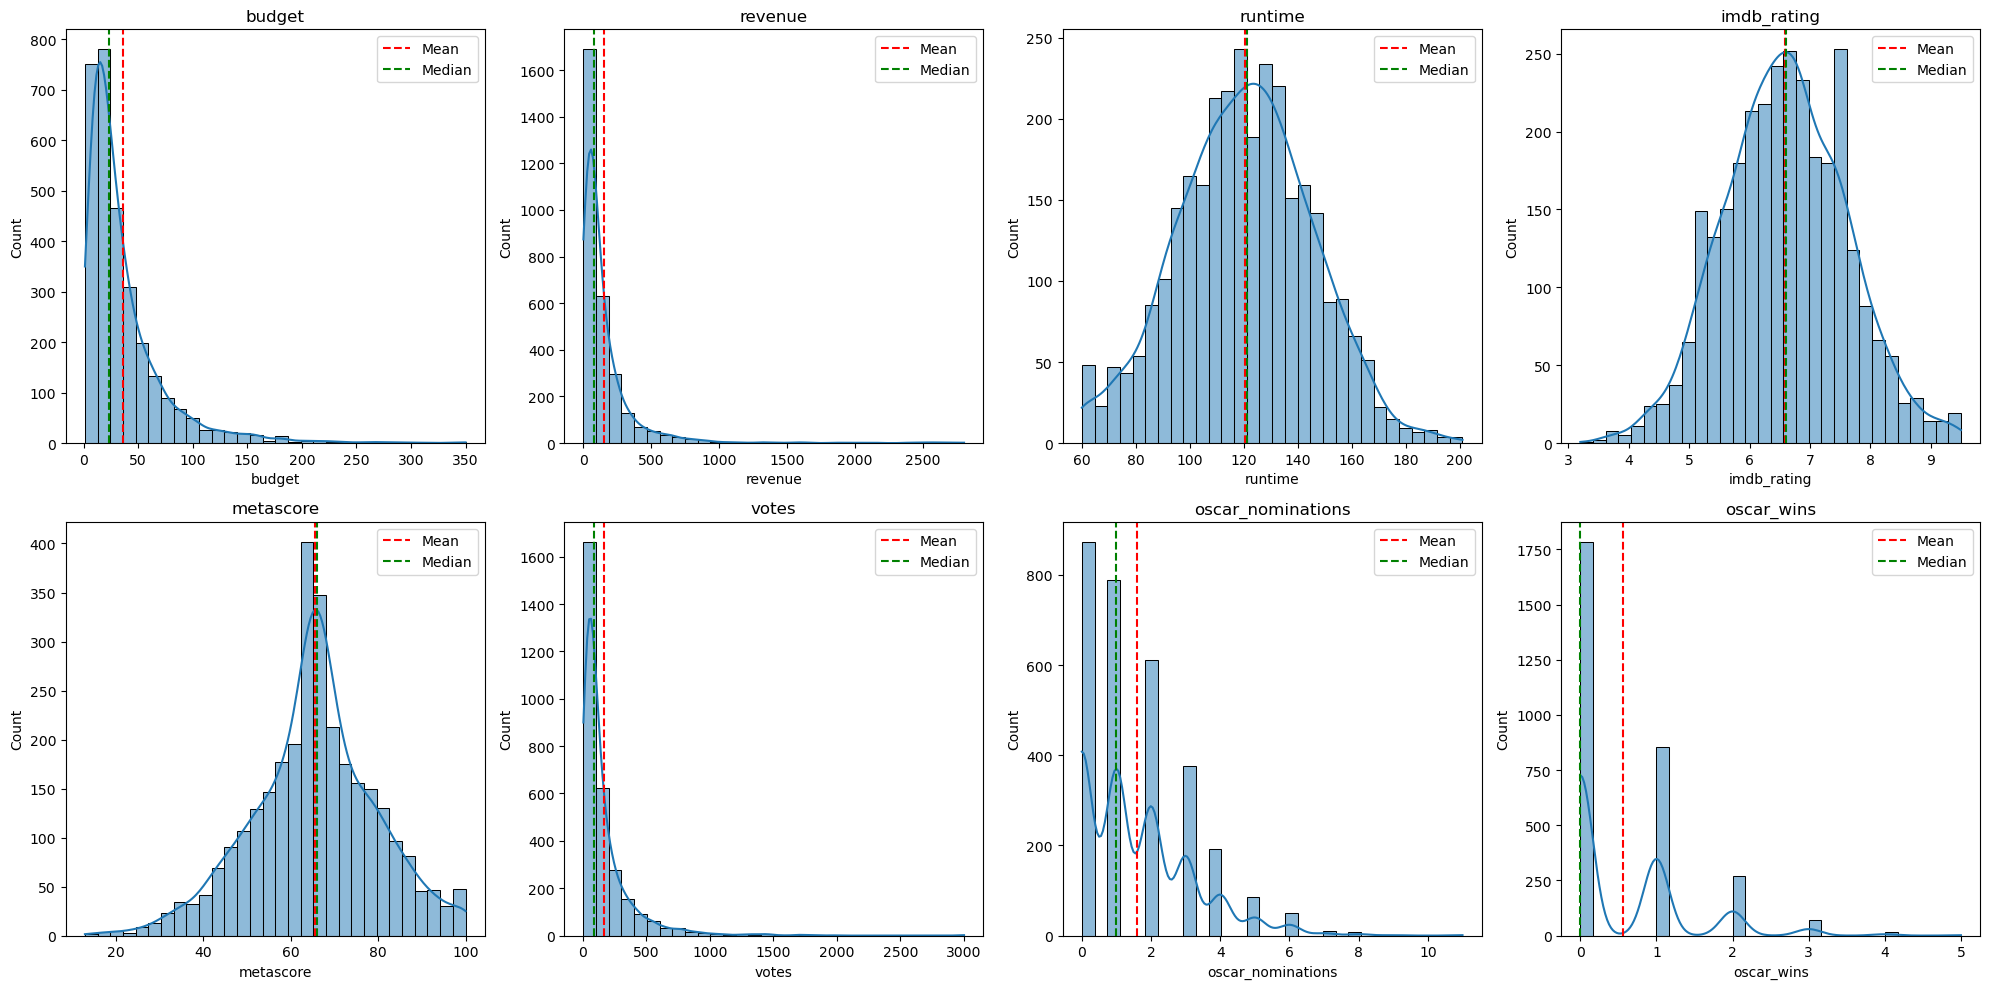

In [66]:
'''3.1'''

import matplotlib.pyplot as plt
import seaborn as sns

numerical_cols = [
    "budget","revenue","runtime",
    "imdb_rating","metascore",
    "votes","oscar_nominations","oscar_wins"
]

fig, axes = plt.subplots(2, 4, figsize=(20,10))

for i, col in enumerate(numerical_cols):
    
    row = i // 4
    col_index = i % 4
    
    # Histogram + Density
    sns.histplot(df[col], kde=True, ax=axes[row, col_index], bins=30)
    
    axes[row, col_index].axvline(df[col].mean(), color='red', linestyle='--', label='Mean')
    axes[row, col_index].axvline(df[col].median(), color='green', linestyle='--', label='Median')
    axes[row, col_index].set_title(col)
    axes[row, col_index].legend()

plt.tight_layout()
plt.show()

In [70]:
'''3.2'''

'''Identify Outliers (IQR Method)'''
def detect_outliers(column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    return df[(df[column] < lower) | (df[column] > upper)]

out_budget = detect_outliers("budget")
out_revenue = detect_outliers("revenue")
out_votes = detect_outliers("votes")

In [72]:
'''Create outliers_df'''
outliers_df = pd.concat([out_budget, out_revenue, out_votes]).drop_duplicates()
len(outliers_df)

564

In [74]:
'''% of Total Revenue from Outliers'''
percentage = outliers_df["revenue"].sum() / df["revenue"].sum() * 100
percentage

49.87204318455221

In [76]:
'''Investigate 5 Specific Outliers'''
outliers_df.sort_values("revenue", ascending=False).head(5)[
    ["title","genre","budget","revenue","imdb_rating"]
]

,title,genre,budget,revenue,imdb_rating
2925,Movie 2926,Comedy,295.28,2800.00,6.0
1610,Movie 1611,Thriller,284.23,2800.00,7.2
1975,Movie 1976,Sci-Fi,209.99,2702.20,7.0
1280,Movie 1281,Sci-Fi,242.61,2670.61,5.0
326,Movie 327,Comedy,200.33,2613.96,5.8


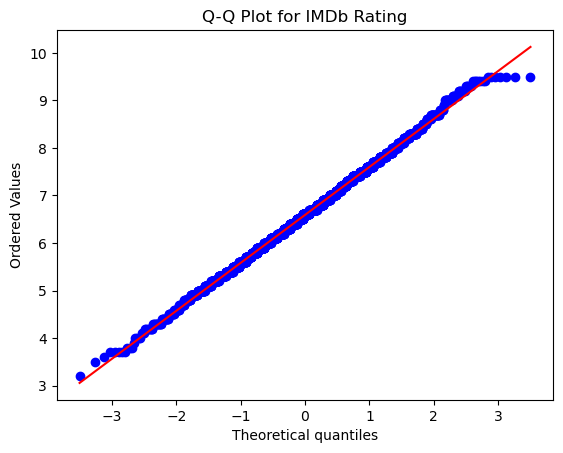

In [80]:
'''3.3'''

'''Q-Q Plot: If points follow diagonal → approximately normal.'''
import scipy.stats as stats

stats.probplot(df["imdb_rating"], dist="norm", plot=plt)
plt.title("Q-Q Plot for IMDb Rating")
plt.show()

In [82]:
'''68-95-99.7 Rule'''
mean = df["imdb_rating"].mean()
std = df["imdb_rating"].std()

within1 = df[(df["imdb_rating"] >= mean-std) &
             (df["imdb_rating"] <= mean+std)].shape[0] / len(df) * 100

within2 = df[(df["imdb_rating"] >= mean-2*std) &
             (df["imdb_rating"] <= mean+2*std)].shape[0] / len(df) * 100

within3 = df[(df["imdb_rating"] >= mean-3*std) &
             (df["imdb_rating"] <= mean+3*std)].shape[0] / len(df) * 100

within1, within2, within3

(67.73333333333333, 95.36666666666666, 99.93333333333332)

In [88]:
'''4.1'''

'''orrelation Matrix'''
numerical_cols = [
    "budget","revenue","runtime",
    "imdb_rating","metascore",
    "votes","oscar_nominations","oscar_wins"
]

corr_matrix = df[numerical_cols].corr()
corr_matrix.round(3)

,budget,revenue,runtime,imdb_rating,metascore,votes,oscar_nominations,oscar_wins
budget,1.000,0.737,-0.030,0.008,0.026,-0.025,-0.021,-0.035
revenue,0.737,1.000,-0.029,-0.006,0.012,-0.023,-0.020,-0.021
runtime,-0.030,-0.029,1.000,-0.012,-0.013,-0.014,-0.012,-0.022
imdb_rating,0.008,-0.006,-0.012,1.000,0.590,-0.019,0.592,0.392
metascore,0.026,0.012,-0.013,0.590,1.000,0.001,0.344,0.215
votes,-0.025,-0.023,-0.014,-0.019,0.001,1.000,-0.007,-0.003
oscar_nominations,-0.021,-0.020,-0.012,0.592,0.344,-0.007,1.000,0.673
oscar_wins,-0.035,-0.021,-0.022,0.392,0.215,-0.003,0.673,1.000


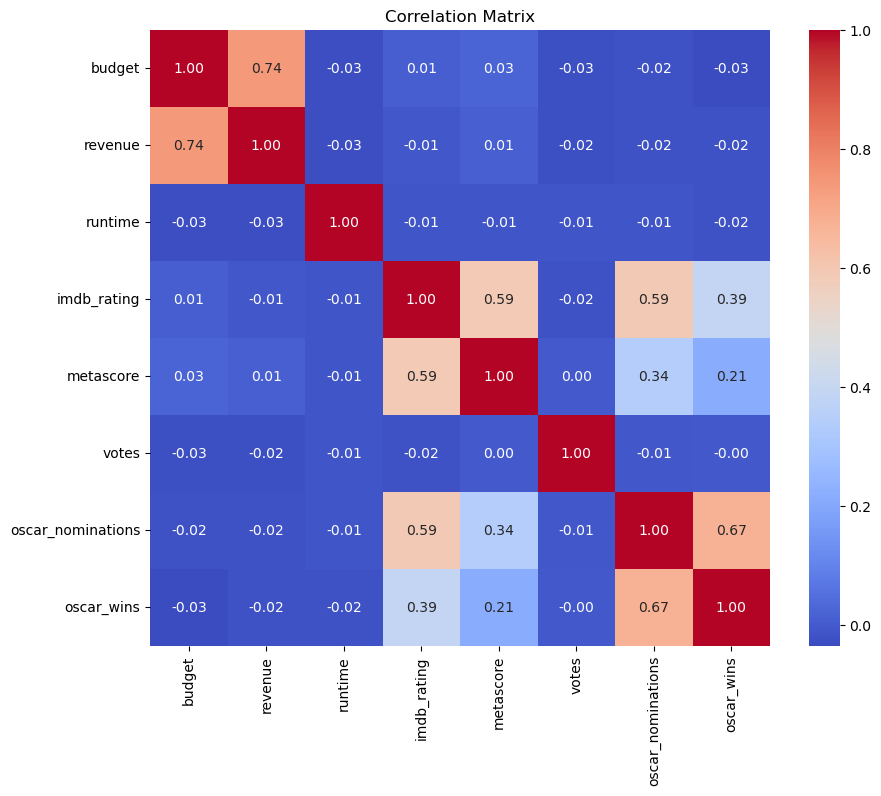

In [90]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

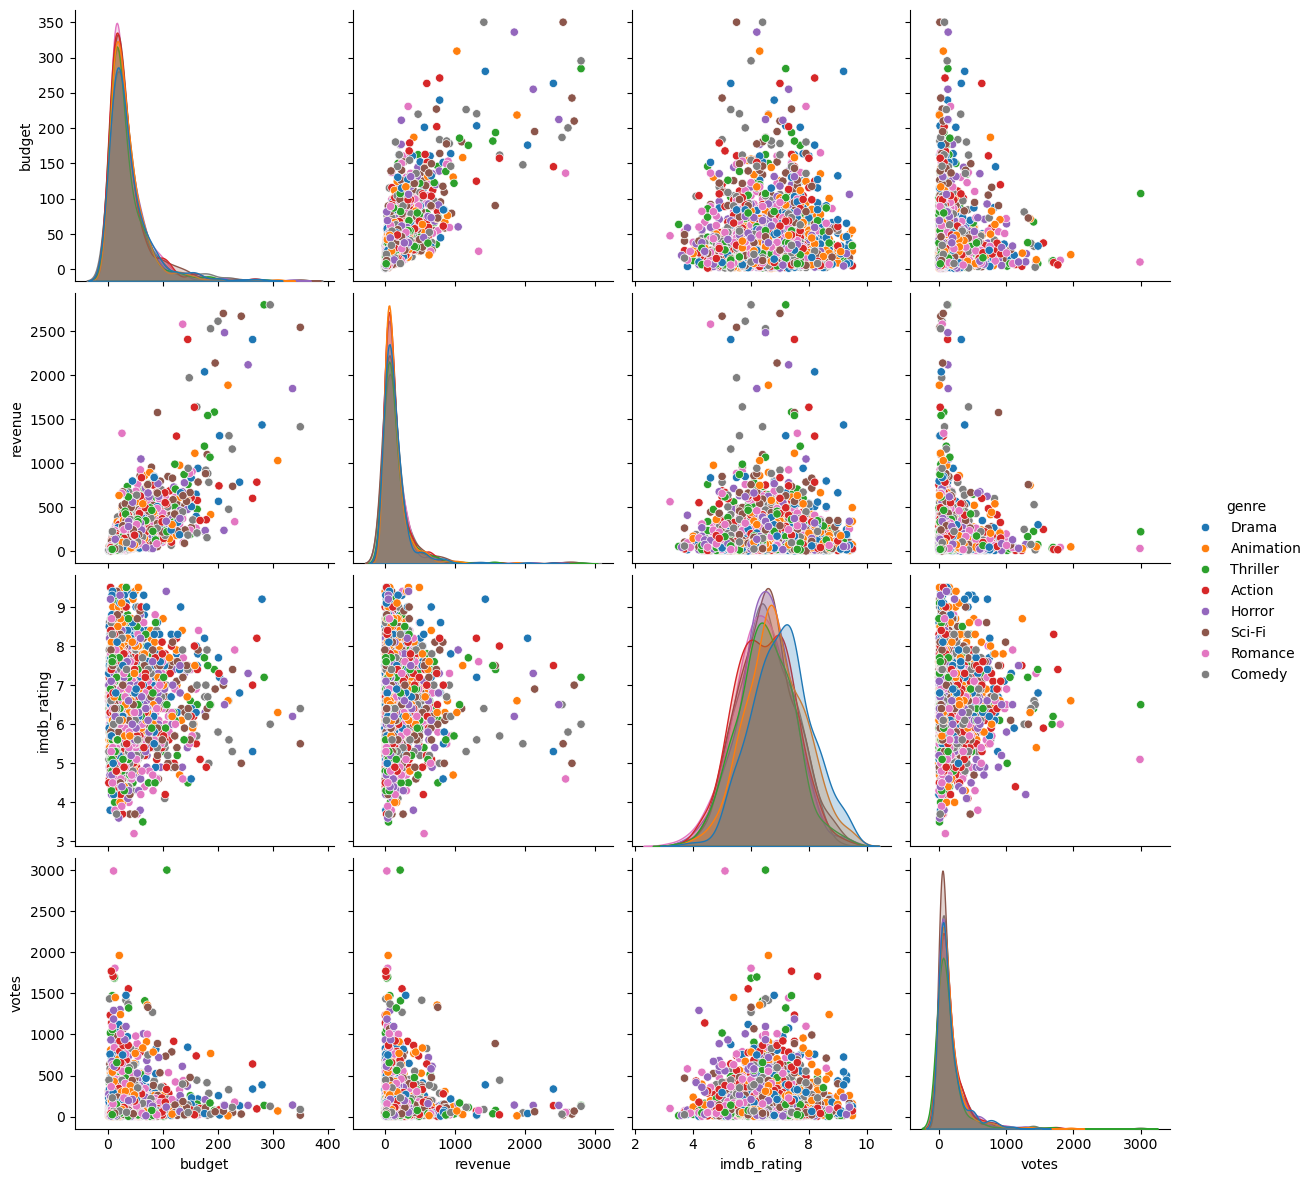

In [92]:
'''4.2'''

import seaborn as sns

scatter_cols = ["budget", "revenue", "imdb_rating", "votes"]

sns.pairplot(
    df,
    vars=scatter_cols,
    hue="genre",
    diag_kind="kde",
    height=3
)

plt.show()

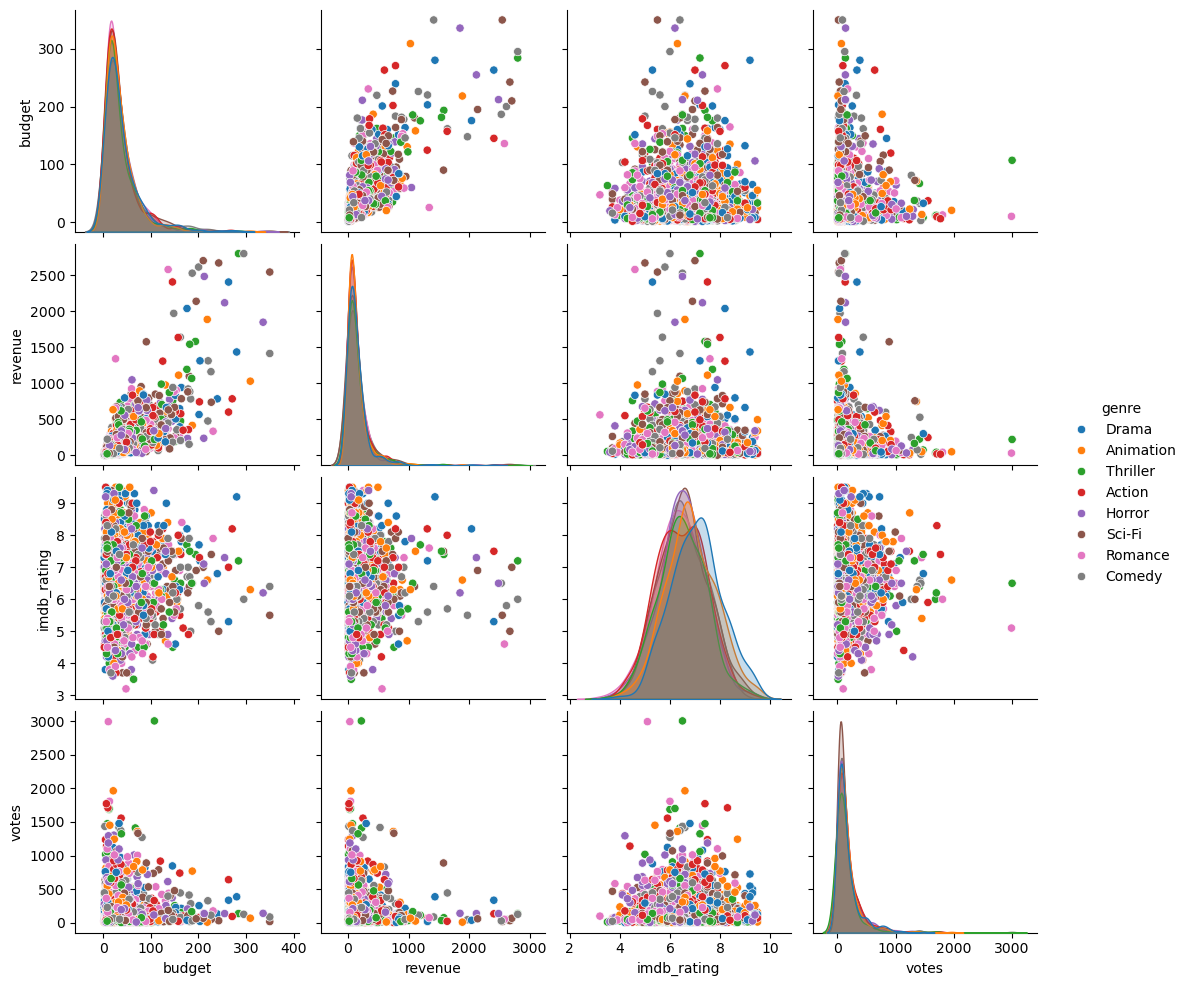

In [94]:
g = sns.pairplot(
    df,
    vars=scatter_cols,
    hue="genre",
    diag_kind="kde"
)

g.fig.set_size_inches(12,10)
plt.show()

In [96]:
'''4.3'''

df["profit_margin"] = np.where(
    df["budget"] > 0,
    (df["revenue"] - df["budget"]) / df["budget"],
    np.nan
)

In [98]:
df[["profit_margin","imdb_rating"]].corr()

,profit_margin,imdb_rating
profit_margin,1.000000,0.000083
imdb_rating,0.000083,1.000000


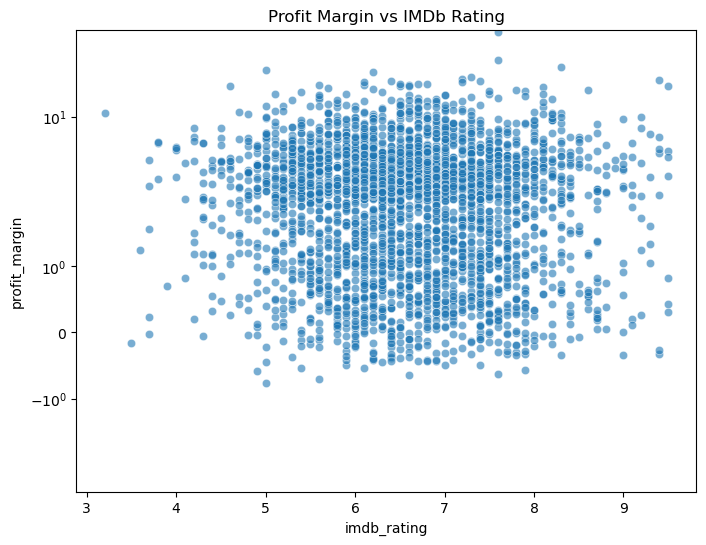

In [100]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="imdb_rating",
    y="profit_margin",
    alpha=0.6
)

plt.yscale("symlog")  # handles large spread
plt.title("Profit Margin vs IMDb Rating")
plt.show()

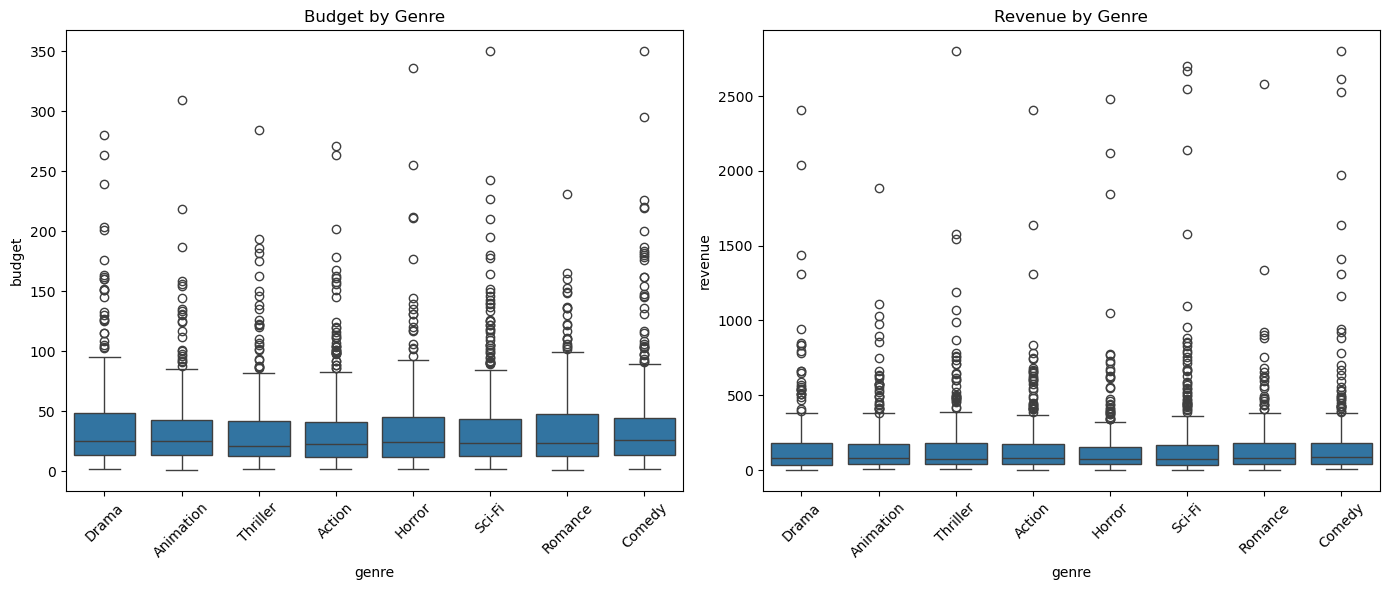

In [102]:
'''5.1'''

plt.figure(figsize=(14,6))

plt.subplot(1,2,1)
sns.boxplot(data=df, x="genre", y="budget")
plt.xticks(rotation=45)
plt.title("Budget by Genre")

plt.subplot(1,2,2)
sns.boxplot(data=df, x="genre", y="revenue")
plt.xticks(rotation=45)
plt.title("Revenue by Genre")

plt.tight_layout()
plt.show()

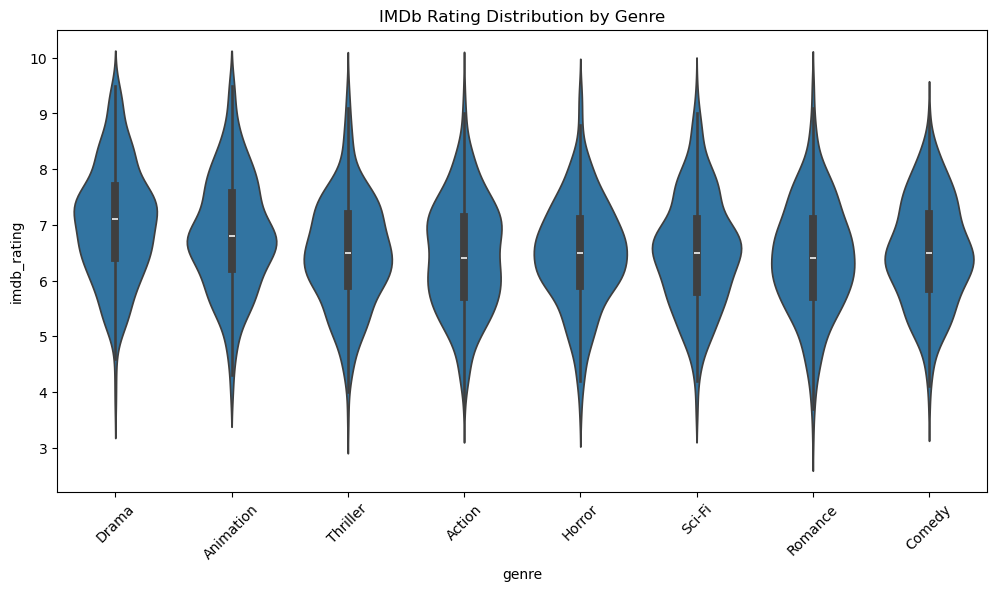

In [106]:
'''IMDb Rating — Violin Plots'''
plt.figure(figsize=(12,6))
sns.violinplot(data=df, x="genre", y="imdb_rating")
plt.xticks(rotation=45)
plt.title("IMDb Rating Distribution by Genre")
plt.show()

In [108]:
'''Profitability — Average Profit Margin by Genre'''

profit_by_genre = df.groupby("genre")["profit_margin"].mean().sort_values(ascending=False)
profit_by_genre

genre
Action       3.403968
Thriller     3.392471
Comedy       3.236549
Romance      3.230574
Animation    3.169065
Sci-Fi       3.048293
Horror       2.989371
Drama        2.942004
Name: profit_margin, dtype: float64

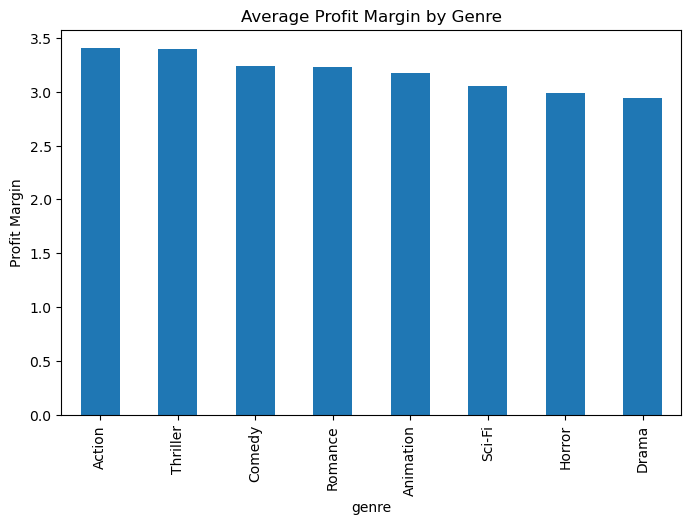

In [110]:
profit_by_genre.plot(kind="bar", figsize=(8,5))
plt.title("Average Profit Margin by Genre")
plt.ylabel("Profit Margin")
plt.show()

In [112]:
'''Awards - Total Oscar Wins by Genre'''
oscar_by_genre = df.groupby("genre")["oscar_wins"].sum().sort_values(ascending=False)
oscar_by_genre

genre
Drama        262
Comedy       228
Animation    226
Horror       211
Sci-Fi       198
Action       196
Thriller     190
Romance      177
Name: oscar_wins, dtype: int64

In [116]:
'''ANSWER QUESTIONS'''

'''1'''
df.groupby("genre")["budget"].median().sort_values(ascending=False)

genre
Comedy       25.730
Drama        25.665
Animation    25.195
Horror       24.045
Sci-Fi       23.460
Romance      23.260
Action       22.760
Thriller     21.015
Name: budget, dtype: float64

In [118]:
'''2'''
df.groupby("genre")["imdb_rating"].std().sort_values()

genre
Comedy       0.944941
Horror       0.950426
Thriller     0.967677
Action       0.997104
Sci-Fi       0.998235
Romance      1.008162
Animation    1.019193
Drama        1.020762
Name: imdb_rating, dtype: float64

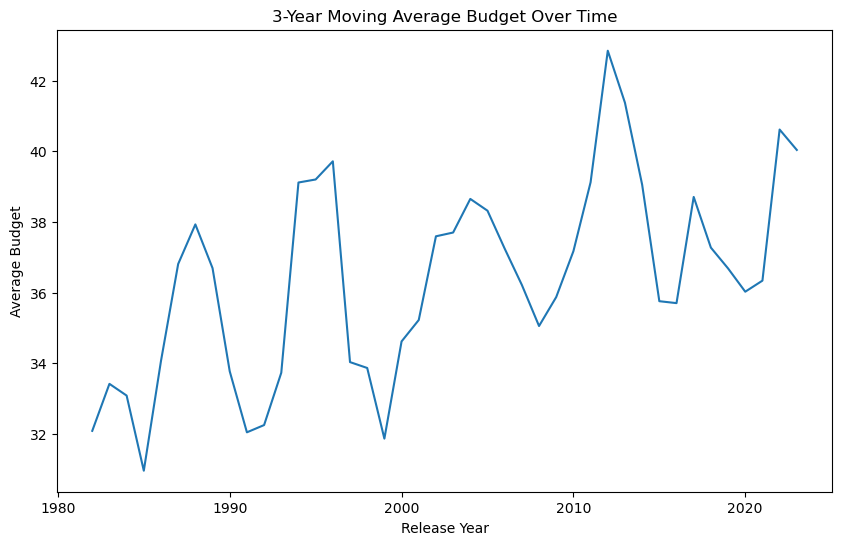

In [120]:
'''5.2'''

budget_trend = df.groupby("release_year")["budget"].mean()
budget_ma = budget_trend.rolling(3).mean()

plt.figure(figsize=(10,6))
plt.plot(budget_ma)
plt.title("3-Year Moving Average Budget Over Time")
plt.xlabel("Release Year")
plt.ylabel("Average Budget")
plt.show()

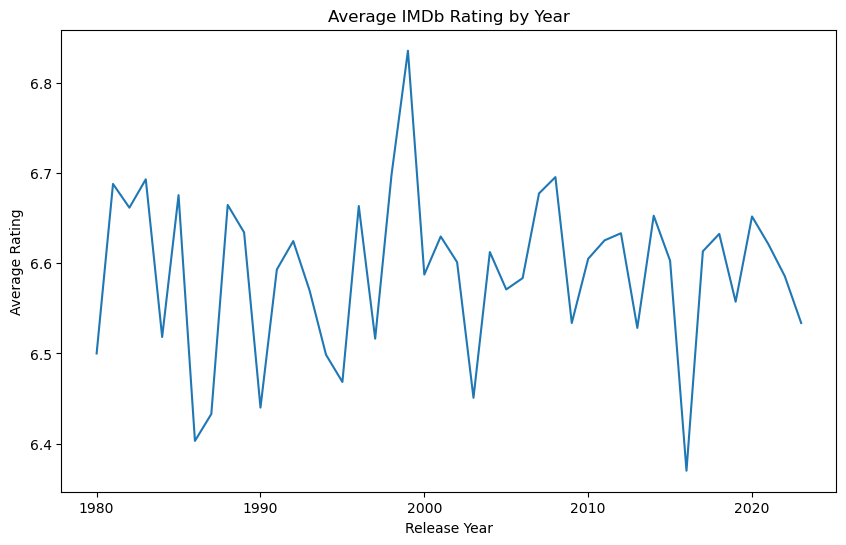

In [122]:
rating_trend = df.groupby("release_year")["imdb_rating"].mean()

plt.figure(figsize=(10,6))
plt.plot(rating_trend)
plt.title("Average IMDb Rating by Year")
plt.xlabel("Release Year")
plt.ylabel("Average Rating")
plt.show()

In [126]:
'''Close to 0 → no major trend.'''
rating_trend.corr(pd.Series(rating_trend.index))

nan

In [128]:
'''5.3'''

top_directors = df["director"].value_counts().head(10)
top_directors

director
Patty Jenkins        320
Steven Spielberg     308
Denis Villeneuve     306
Martin Scorsese      303
Quentin Tarantino    303
James Cameron        297
Christopher Nolan    295
Greta Gerwig         292
Ridley Scott         292
Alfonso Cuarón       284
Name: count, dtype: int64

In [130]:
top_director_names = top_directors.index

director_stats = df[df["director"].isin(top_director_names)] \
    .groupby("director") \
    .agg({
        "imdb_rating":"mean",
        "profit_margin":"mean",
        "oscar_nominations":"mean"
    })

director_stats

,imdb_rating,profit_margin,oscar_nominations
director,,,
Alfonso Cuarón,6.608803,3.243392,1.728873
Christopher Nolan,6.645763,3.091015,1.705085
Denis Villeneuve,6.512092,3.072892,1.516340
Greta Gerwig,6.673288,3.023387,1.616438
James Cameron,6.565320,3.323416,1.390572
Martin Scorsese,6.505281,3.066144,1.600660
Patty Jenkins,6.556563,3.307614,1.559375
Quentin Tarantino,6.599670,3.306999,1.600660
Ridley Scott,6.622603,2.996799,1.660959
